# Medication Sales Across Pharmacies

This dataset, obtained from a simulated POS database, provides information on clients, products and sales transactions.

### Library Imports

The necessary libraries for data analysis and visualization are imported:
- `pandas` for data manipulation using DataFrames.
- `matplotlib.pyplot` for creating basic and customizable plots. 
- `seaborn` for statistical data visualization
- `numpy` for handles numerical operations and arrays.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Loading the Pharmacies Dataset

This section loads the dataset containing pharmacy sales data into a pandas DataFrame, allowing for further data manipulation, analysis and visualization.

In [2]:
try:
  pharmacy = pd.read_csv("cleaned_pharmacies_sales.csv")
  df_pharmacy = pharmacy.copy()
  print("File was loaded with success and save as dataframe!")
  print(f"Count of rows and columns: {df_pharmacy.shape}")
except FileNotFoundError:
  print("Error: pharmacies_sales.csv was not found.")

File was loaded with success and save as dataframe!
Count of rows and columns: (1000, 17)


Information of the `df_pharmacy` DataFrame

In [3]:
df_pharmacy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1000 non-null   object 
 1   Year            1000 non-null   int64  
 2   Month_Name      1000 non-null   object 
 3   Month           1000 non-null   int64  
 4   Day             1000 non-null   int64  
 5   Season          1000 non-null   object 
 6   Location_Store  1000 non-null   object 
 7   Gender          1000 non-null   object 
 8   Age             1000 non-null   int64  
 9   Type_Plan       1000 non-null   object 
 10  City_Client     1000 non-null   object 
 11  Name_Product    1000 non-null   object 
 12  Category        1000 non-null   object 
 13  Covered_Plan    1000 non-null   object 
 14  Unit_Price      1000 non-null   float64
 15  Quantity        1000 non-null   int64  
 16  Total_Sale      1000 non-null   float64
dtypes: float64(2), int64(5), object(10

**Head of the `df_pharmacy` dataframe**

In [4]:
df_pharmacy.head()

,Date,Year,Month_Name,Month,Day,Season,Location_Store,Gender,Age,Type_Plan,City_Client,Name_Product,Category,Covered_Plan,Unit_Price,Quantity,Total_Sale
0,2024-06-08,2024,June,6,8,Summer,Arecibo,M,34,MCS,San Juan,Tiras reactivas diabetes,Diabetes,Y,55.67,6,334.02
1,2024-06-25,2024,June,6,25,Summer,Aguadilla,M,34,MCS,San Juan,Tiras reactivas diabetes,Diabetes,N,20.66,1,20.66
2,2024-07-02,2024,July,7,2,Summer,Humacao,M,34,MCS,San Juan,Tiras reactivas diabetes,Diabetes,Y,96.65,4,386.60
3,2024-07-02,2024,July,7,2,Summer,Carolina,M,34,MCS,San Juan,Vitamina D 2000UI,Suplementos,Y,82.12,5,410.60
4,2024-01-05,2024,January,1,5,Winter,Caguas,F,39,MCS,Caguas,Acetaminofen 500 mg,Analgesico,Y,8.99,3,26.97


In [5]:
def show_value(df, column):
    print(df[column].value_counts().sort_index())

try:
    column_name = input("Enter the column name: ").title() or "Season"

    if column_name.strip():
        print("You entered an empty value.")
    else:
        show_value(df_pharmacy, column_name)

except Exception as e:
    print(f"An error ocurred: {e}")

You entered an empty value.


### Descriptive Analysis

Descriptive analysis summarizes and describes the main features of a dataset. 
It helps understand patterns, trends, and basic statistics.

In [6]:
average_age = df_pharmacy['Age'].mean()
print(f"The average age of customers is {average_age:.0f} years")

The average age of customers is 55 years


In [7]:
city_distribution = df_pharmacy['City_Client'].value_counts()
print("Customer distribution by city (top 5):")
print(city_distribution.head())

Customer distribution by city (top 5):
City_Client
Carolina    113
Humacao     112
Ponce       109
Caguas      105
Bayamon     100
Name: count, dtype: int64


In [8]:
total_sales_category = df_pharmacy.groupby('Category')['Total_Sale'].sum()
print("Total sales per product category: ")
print(total_sales_category.sort_values())

Total sales per product category: 
Category
Bebes                 1109.56
Primeros auxilios     1873.07
Antigripales          2122.15
Gastro                5422.08
Analgesico            9566.77
Cuidado personal     10740.54
Suplementos          12165.59
Diabetes             40851.71
Name: Total_Sale, dtype: float64


In [9]:
product_sales = df_pharmacy.groupby('Name_Product')['Total_Sale'].sum()
print("Product with the highest total sales: ")
print(product_sales.sort_values(ascending=False).head(1))

Product with the highest total sales: 
Name_Product
Tiras reactivas diabetes    23514.93
Name: Total_Sale, dtype: float64


In [10]:
print("Total sales by month: ")
df_pharmacy.groupby(['Month', 'Month_Name'])['Total_Sale'].sum()

Total sales by month: 


Month  Month_Name
1      January       24724.83
2      February       5731.57
3      March          9887.40
4      April          7993.91
5      May            5132.13
6      June          14475.61
7      July           4642.21
8      August         2304.06
9      September      2657.32
10     October        2366.65
11     November       2195.42
12     December       1740.36
Name: Total_Sale, dtype: float64

In [11]:
print("Total sales by season: ")
df_pharmacy.groupby('Season')['Total_Sale'].sum()

Total sales by season: 


Season
Fall       7219.39
Spring    23013.44
Summer    21421.88
Winter    32196.76
Name: Total_Sale, dtype: float64

In [12]:
print("Type of Plan among customers:")
df_pharmacy['Type_Plan'].value_counts()

Type of Plan among customers:


Type_Plan
MMM              504
MCS              448
Triple S          17
First Medical     16
Medicaid          15
Name: count, dtype: int64

In [13]:
covered_sales = df_pharmacy[df_pharmacy['Covered_Plan'] == 'N']['Total_Sale'].sum()
total_sales = df_pharmacy['Total_Sale'].sum()
percentage_covered = (covered_sales / total_sales) * 100

print(f"Total sales from products covered by a plan: ${covered_sales:,.2f}")
print(f"This represents {percentage_covered:.2f}% of total sales")

Total sales from products covered by a plan: $18,661.93
This represents 22.26% of total sales


In [14]:
average_quantity = df_pharmacy['Quantity'].mean()
print(f"The average quantity of products purchased per customer is {average_quantity:.2f}")

The average quantity of products purchased per customer is 2.34


In [15]:
season_product = df_pharmacy.groupby(['Season', 'Name_Product'])['Quantity'].sum().reset_index()
most_popular_season = season_product.loc[season_product.groupby('Season')['Quantity'].idxmax()]
print("Most popular products per season:")
print(most_popular_season)

Most popular products per season:
     Season              Name_Product  Quantity
21     Fall  Tiras reactivas diabetes        31
40   Spring         Metformina 500 mg       118
88   Summer  Tiras reactivas diabetes        47
117  Winter  Tiras reactivas diabetes       219


In [16]:
gender_avg_quantity = df_pharmacy.groupby('Gender')['Quantity'].mean()
print("Average quantity purchased by gender:")
print(gender_avg_quantity)

Average quantity purchased by gender:
Gender
F    2.260081
M    2.410714
Name: Quantity, dtype: float64


In [17]:
city_sales = df_pharmacy.groupby('Location_Store')['Total_Sale'].sum().sort_values()
print("\nTotal sales by location store:")
print(city_sales)


Total sales by location store:
Location_Store
Aguadilla      391.94
Yauco          646.65
Fajardo        756.06
San Juan      1127.06
Toa Baja      6029.09
Guaynabo      7928.16
Mayaguez      8551.66
Humacao       8849.59
Carolina      8934.85
Bayamon       9606.22
Arecibo       9615.84
Caguas       10315.25
Ponce        11099.10
Name: Total_Sale, dtype: float64


### Key Visualizations

Key visualizations are charts, graphs, or plots that help communicate the most important insights from your data clearly and quickly.

**Total Sales by Store**

This chart display the total sales generated by each pharmacy location during the year 2024.

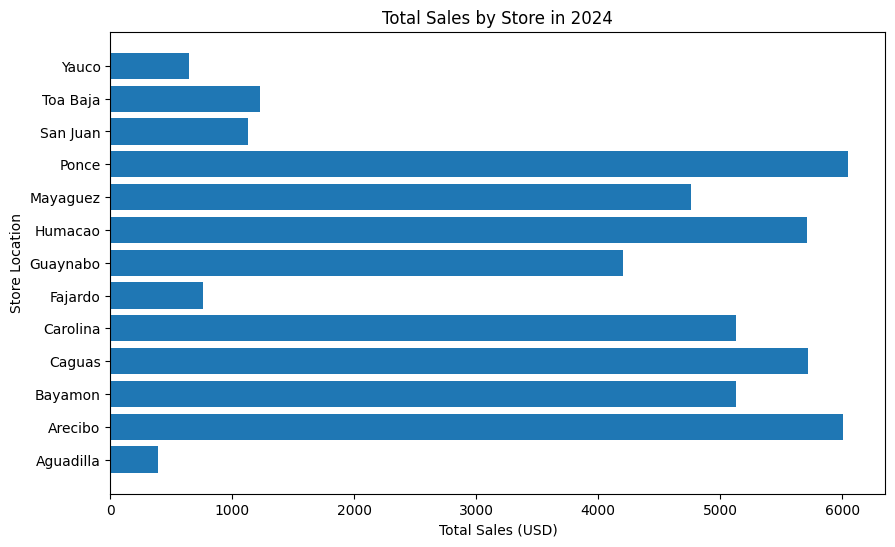

In [18]:
# Filter the data for sales in the year 2024
sales_2024 = df_pharmacy.query("Year == 2024")

# Group total sales by store location and sum the sales
sales_store = sales_2024.groupby("Location_Store")["Total_Sale"].sum()

# Plot total sales by store for 2024.
plt.figure(figsize=(10,6))
plt.barh(sales_store.index, sales_store.values)
plt.xlabel("Total Sales (USD)")
plt.ylabel("Store Location")
plt.title("Total Sales by Store in 2024")
plt.show()

**Sales Distribution by Product Category**

This code filters the pharmacy sales dataset to include only transactions from the year 2023. Finally, it creates a pie chart to visualize the proportion of total sales contributed by each category.

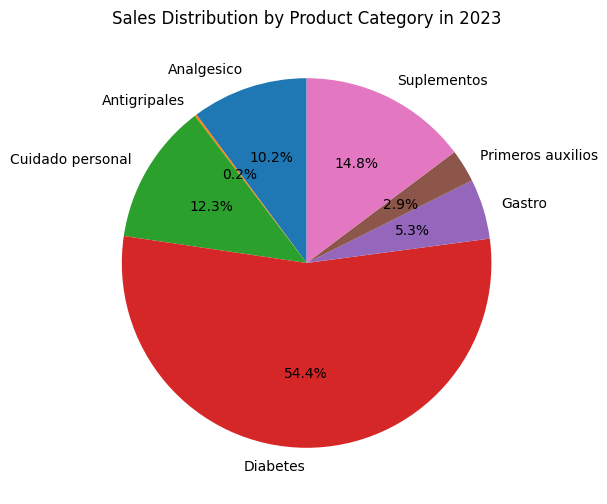

In [42]:
# Filter the data for the year 2023
df_2023 = df_pharmacy.query('Year == 2023')

# Group sales by product category and sum total sales
category_sales = df_2023.groupby('Category')['Total_Sale'].sum()

# Plot a pie chart to show the proportion of sales by category in 2023
plt.figure(figsize=(6,6))
plt.pie(category_sales, labels=category_sales.index, 
    autopct='%1.1f%%', startangle=90)
plt.title('Sales Distribution by Product Category in 2023')
plt.show()

**Total Sales by Month**

This line chart shows the total sales for each month, with separate lines for each year. It highlights monthly trends and allows comparison of sales performance between years.

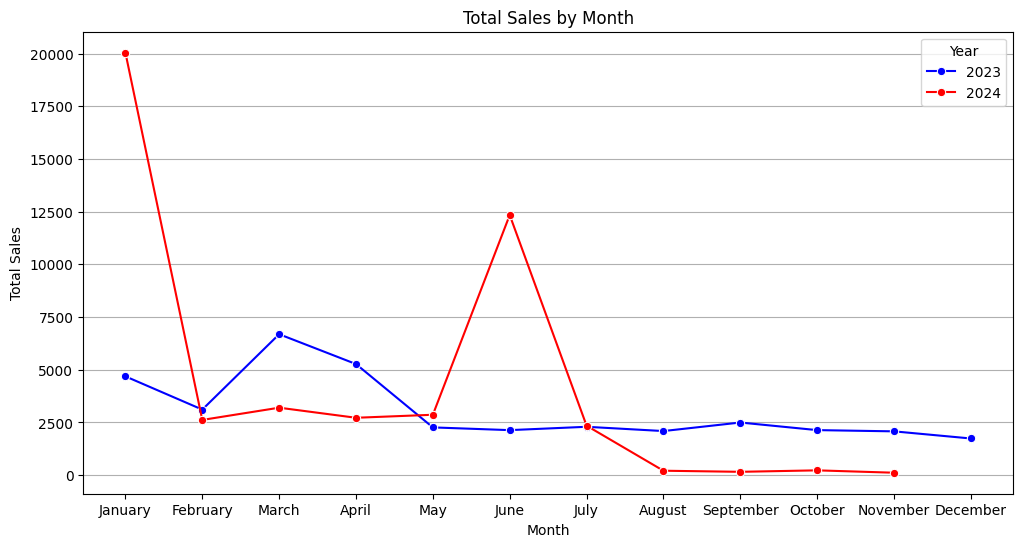

In [20]:
# Group the DataFrame by year, month, and month_name
monthly_sales = df_pharmacy.groupby(['Year', 'Month', 'Month_Name'])

# Calculate the sum of total sales for each year-month 
monthly_sales = monthly_sales['Total_Sale'].sum()

# Reset the index to convert the resulting Series into a DataFrame
monthly_sales = monthly_sales.reset_index()

# Create a line plot to visualize monthly sales trends
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='Month_Name', y='Total_Sale',
    hue='Year', marker='o', palette=['blue', 'red'])
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend(title='Year')
plt.grid(axis='y')
plt.show()

**Scatter Plot of Age vs Total Sales**

This scatter plot displays each client’s total sales according to their age. The red line represents the linear regression, showing the general trend of how sales change with age.

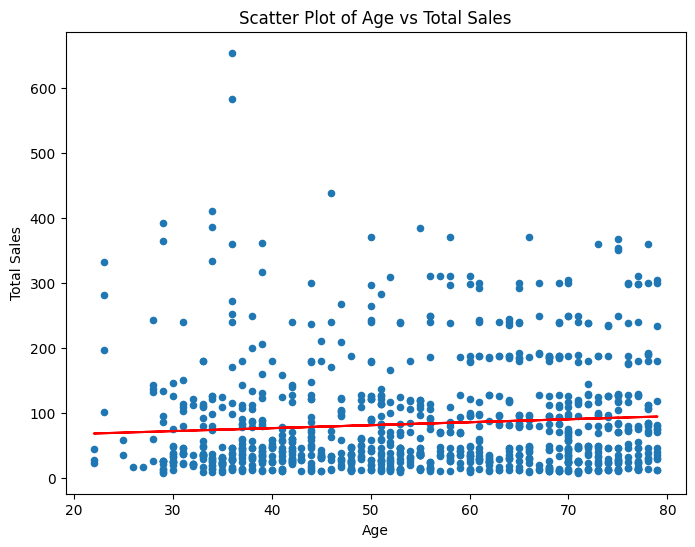

In [ ]:
# Create a scatter plot of Age vs Total_Sale
df_pharmacy.plot(kind='scatter', x='Age', y='Total_Sale', figsize=(8,6))
plt.xlabel('Age')
plt.ylabel('Total Sales')
plt.title('Scatter Plot of Age vs Total Sales')

# Calculate the slope (m) and intercept (b) of the linear regression line
m, b = np.polyfit(df_pharmacy['Age'], df_pharmacy['Total_Sale'], 1)
line = m * df_pharmacy['Age'] + b

# Plot the regression line in red and add a label for the legend
plt.plot(df_pharmacy['Age'], line, color='red', label='Linear Regression')

**Boxplots of Age and Total Sales**

This figure displays separate boxplots for the `Age` and `Total_Sale` columns in the `df_pharmacy` DataFrame.

Text(0.5, 0.98, 'Boxplots of Age and Total Sales')

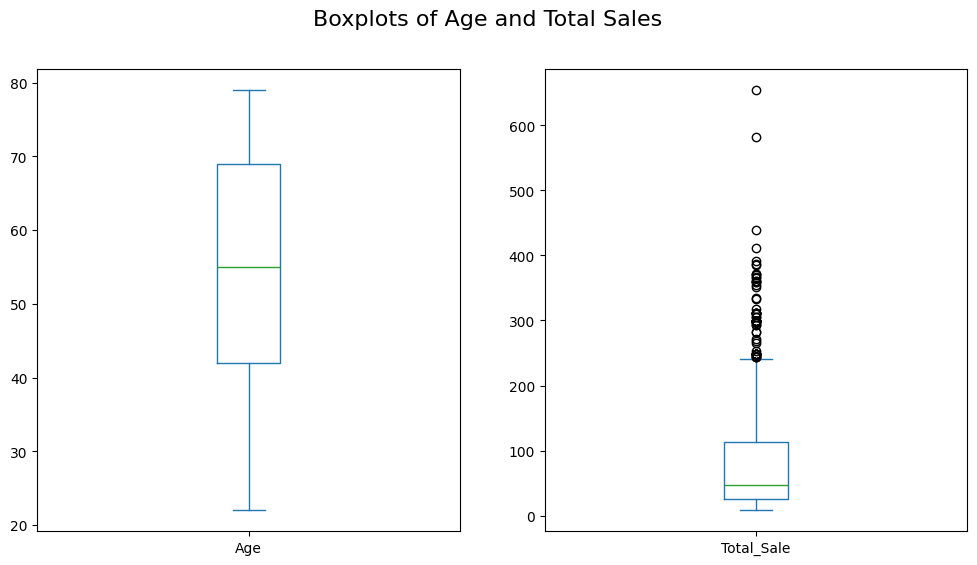

In [ ]:
# Select columns for the boxplot
boxplot_data = df_pharmacy[['Age', 'Total_Sale']]

# Create boxplots as subplots in a single row with 2 columns
boxplot_data.plot(kind='box', subplots=True, layout=(1,2), 
    figsize=(12, 6))

plt.suptitle('Boxplots of Age and Total Sales', fontsize=16)